# Movie Review Sentiment Analysis — V3 (RoBERTa)

This is version 3 of the IMDB sentiment analysis project.

| Version | Model | F1 Score |
|---------|-------|----------|
| V1 | TF-IDF + Linear SVM | 0.9135 |
| V2 | DistilBERT (fine-tuned) | 0.9224 |
| V3 | RoBERTa-base (fine-tuned) | TBD |

**What changed from V2:**
- `roberta-base` instead of `distilbert-base-uncased` — RoBERTa is trained with more data and a better
  pre-training procedure, and consistently outperforms DistilBERT on sentiment tasks
- `max_length=512` instead of 256 — captures the full review rather than cutting it off halfway
- `learning_rate=1e-5` instead of 2e-5 — more conservative update for longer sequences
- 4 epochs instead of 3 — V2 training loss suggested the model had not fully converged

**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

## Table of Contents

1. [Setup](#1-setup)
2. [Load Dataset](#2-load-dataset)
3. [Preprocessing](#3-preprocessing)
4. [Tokenization](#4-tokenization)
5. [Model Setup](#5-model-setup)
6. [Training](#6-training)
7. [Evaluation](#7-evaluation)
8. [Comparison: V1 / V2 / V3](#8-comparison-v1--v2--v3)
9. [Error Analysis](#9-error-analysis)
10. [Custom Review Testing](#10-custom-review-testing)
11. [Save Artifacts](#11-save-artifacts)

## 1. Setup

Using `AutoTokenizer` and `AutoModelForSequenceClassification` from Hugging Face — these work
with any model checkpoint, so swapping `roberta-base` for another model later requires changing
only one line.

In [1]:
import os, re, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Training will be very slow on CPU.")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Load Dataset

Same dataset and auto-detection logic as V1 and V2.

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
LOCAL_PATH  = 'dataset/IMDB Dataset.csv'
DATA_PATH   = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (50000, 2)
Columns: ['review', 'sentiment']

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values: 0


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 3. Preprocessing

Same minimal cleaning as V2 — only HTML tags removed. RoBERTa's BPE tokenizer handles
raw text well and aggressive cleaning would strip context the model relies on.

In [3]:
def minimal_clean(text):
    text = re.sub(r'<[^>]+>', ' ', text)   # strip HTML tags
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['label'] = (df['sentiment'] == 'positive').astype(int)

# same 80/20 split and random state across all versions for fair comparison
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

X_train_text = [minimal_clean(t) for t in X_train_raw]
X_test_text  = [minimal_clean(t) for t in X_test_raw]

print(f"Train: {len(X_train_text):,} reviews")
print(f"Test:  {len(X_test_text):,} reviews")
print(f"Class balance (train): {sum(y_train)/len(y_train):.3f} positive")

Train: 40,000 reviews
Test:  10,000 reviews
Class balance (train): 0.500 positive


## 4. Tokenization

RoBERTa uses Byte-Pair Encoding (BPE) rather than WordPiece. The API is identical through
`AutoTokenizer` — the checkpoint name is the only thing that changes.

`max_length=512` is the full context window RoBERTa supports. V2 capped at 256 and was
cutting reviews in half — many IMDB reviews have important sentiment cues in the second half
("...but the ending completely redeemed it").

In [4]:
MODEL_NAME = 'roberta-base'
MAX_LEN    = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    X_train_text,
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    X_test_text,
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

print(f"Tokenization complete.")
print(f"Train: {len(train_encodings['input_ids']):,} x {len(train_encodings['input_ids'][0])} tokens")
print(f"Test:  {len(test_encodings['input_ids']):,} x {len(test_encodings['input_ids'][0])} tokens")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.
Train: 40,000 x 512 tokens
Test:  10,000 x 512 tokens


In [5]:
class SentimentDataset(Dataset):
    # wraps tokenized encodings and integer labels for the Trainer API

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset  = SentimentDataset(test_encodings,  y_test)

print(f"Train dataset: {len(train_dataset):,} samples")
print(f"Test dataset:  {len(test_dataset):,} samples")

Train dataset: 40,000 samples
Test dataset:  10,000 samples


## 5. Model Setup

`roberta-base` has 125M parameters — roughly twice the size of DistilBERT. Like V2, only the
classification head is randomly initialized; everything else loads from the pre-trained checkpoint.

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     124,647,170
Trainable parameters: 124,647,170


In [7]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall':    recall_score(labels, preds),
        'f1':        f1_score(labels, preds)
    }

## 6. Training

Key differences from V2:
- **`learning_rate=1e-5`** — halved from V2. Larger sequences and a bigger model benefit from
  more conservative updates to avoid destabilizing the pre-trained weights
- **`per_device_train_batch_size=16`** — reduced from 32 to fit 512-token sequences in GPU memory
- **4 epochs** — V2 training loss (0.41) indicated the model had not fully converged at 3 epochs

In [8]:
training_args = TrainingArguments(
    output_dir             = './results_v3',
    num_train_epochs       = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate          = 1e-5,
    warmup_steps           = 200,
    weight_decay           = 0.01,
    logging_dir            = './logs_v3',
    logging_steps          = 200,
    eval_strategy          = 'epoch',
    save_strategy          = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1',
    greater_is_better      = True,
    report_to              = 'none',
    fp16                   = torch.cuda.is_available(),
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)

print("Starting training...")
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.316196,0.270961,0.953100,0.942567,0.965000,0.953652
2,0.263476,0.298292,0.951100,0.972158,0.928800,0.949985
3,0.194868,0.383832,0.957300,0.946669,0.969200,0.957802
4,0.140810,0.408795,0.957800,0.952372,0.963800,0.958052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5000, training_loss=0.25796941833496095, metrics={'train_runtime': 8959.1522, 'train_samples_per_second': 17.859, 'train_steps_per_second': 0.558, 'total_flos': 4.20977688576e+16, 'train_loss': 0.25796941833496095, 'epoch': 4.0})

## 7. Evaluation

Final evaluation on the held-out test set.

Accuracy:  0.9578
Precision: 0.9524
Recall:    0.9638
F1 Score:  0.9581

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.95      0.96      5000
    Positive       0.95      0.96      0.96      5000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



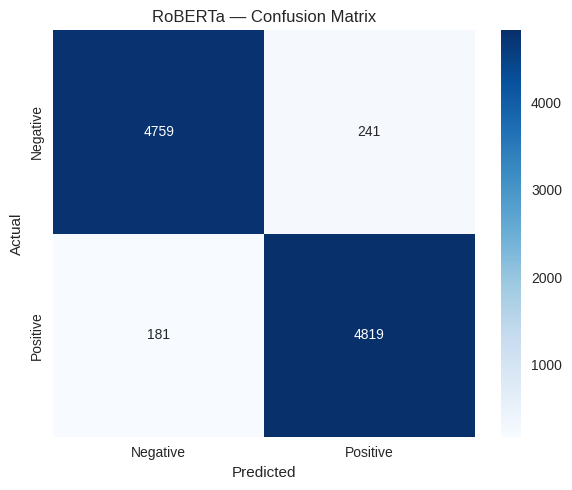

In [9]:
predictions = trainer.predict(test_dataset)
y_pred      = predictions.predictions.argmax(-1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('RoBERTa — Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Comparison: V1 / V2 / V3

All three versions evaluated on the same 10,000-review test set with the same random seed.

                 Accuracy  Precision  Recall      F1
Linear SVM (V1)    0.9132     0.9102  0.9168  0.9135
DistilBERT (V2)    0.9218     0.9155  0.9294  0.9224
RoBERTa (V3)       0.9578     0.9524  0.9638  0.9581


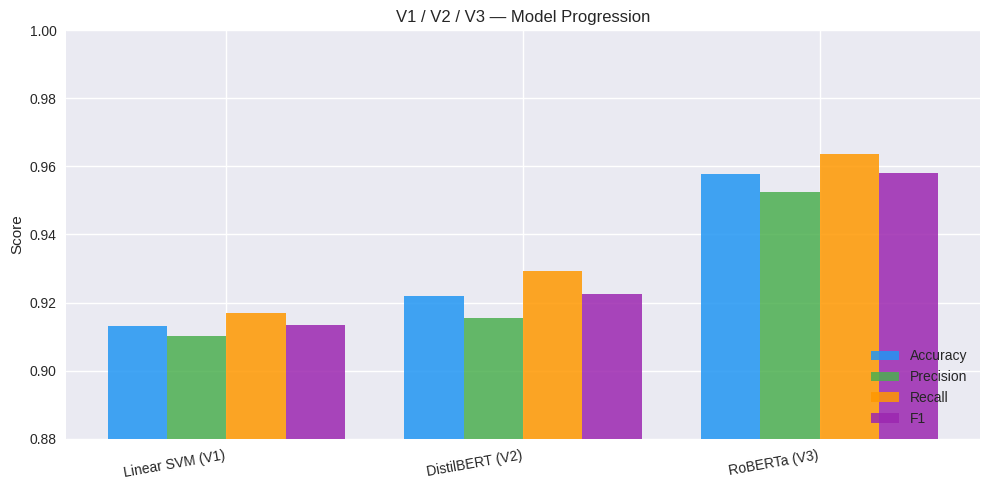

In [10]:
# actual results from previous runs
v_results = {
    'Linear SVM (V1)':  {'Accuracy': 0.9132, 'Precision': 0.9102, 'Recall': 0.9168, 'F1': 0.9135},
    'DistilBERT (V2)':  {'Accuracy': 0.9218, 'Precision': 0.9155, 'Recall': 0.9294, 'F1': 0.9224},
    'RoBERTa (V3)':     {'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
                         'Recall': round(rec, 4),   'F1': round(f1, 4)},
}

comparison = pd.DataFrame(v_results).T
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(comparison))
width  = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, (metric, color) in enumerate(zip(['Accuracy', 'Precision', 'Recall', 'F1'], colors)):
    ax.bar(x + i * width, comparison[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comparison.index, rotation=10, ha='right')
ax.set_ylim(0.88, 1.0)
ax.set_ylabel('Score')
ax.set_title('V1 / V2 / V3 — Model Progression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Error Analysis

Inspecting what the model still gets wrong after the improvements.

In [11]:
errors = []
for text, true_label, pred_label in zip(X_test_text, y_test, y_pred):
    if pred_label != true_label:
        errors.append({
            'text':      text[:250],
            'true':      'Positive' if true_label == 1 else 'Negative',
            'predicted': 'Positive' if pred_label == 1 else 'Negative',
        })

fp = [e for e in errors if e['predicted'] == 'Positive']
fn = [e for e in errors if e['predicted'] == 'Negative']

print(f"Misclassified: {len(errors)} / {len(y_test)} ({100*len(errors)/len(y_test):.2f}% error rate)")
print(f"False Positives (predicted +, actually -): {len(fp)}")
print(f"False Negatives (predicted -, actually +): {len(fn)}")

print("\n--- Sample False Positives ---")
for e in fp[:3]:
    snippet = e['text']
    print(f'  "{snippet}..."')
    print()

print("--- Sample False Negatives ---")
for e in fn[:3]:
    snippet = e['text']
    print(f'  "{snippet}..."')
    print()

Misclassified: 422 / 10000 (4.22% error rate)
False Positives (predicted +, actually -): 241
False Negatives (predicted -, actually +): 181

--- Sample False Positives ---
  "Little Quentin seems to have mastered the art of having the cake and eating it. As usual, the pure sadistic display can be explained as a clever thought-provoking way of sending violence back into the audience's face. Sure, Mr Tarantino. Violence is ..."

  "I am quite a fan of novelist/screenwriter Michael Chabon. His novel "Wonder Boys" became a fantastic movie by Curtis Hanson. His masterful novel "The Amazing Adventures of Kavalier and Clay" won the Pulitzer Prize a few years back, and he had a hand ..."

  "I appeared as an extra and was on location as a journalist covering "The Dain Curse". My involvement was during the segments of this film shot in Jim Thorpe, Pa. (Jim Thorpe was also one of the locations of the 1969 film "The Molly Maguires"). I repo..."

--- Sample False Negatives ---
  "I admit creating 

## 10. Custom Review Testing

Testing on hand-written reviews to check real-world generalization.

In [12]:
def predict_review(text, model, tokenizer, device):
    # returns (label_string, confidence_float)
    model.eval()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    inputs = tokenizer(
        text, truncation=True, padding=True,
        max_length=MAX_LEN, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs      = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_class = probs.argmax().item()
    confidence = probs.max().item()
    label      = 'POSITIVE' if pred_class == 1 else 'NEGATIVE'
    return label, confidence


test_reviews = [
    "This film was absolutely breathtaking. The performances were outstanding and the story kept me engaged throughout.",
    "I wasted two hours of my life on this. The acting was terrible and the plot made no sense whatsoever.",
    "It was okay. Some parts were genuinely good, others were painfully slow. Not the worst I have seen.",
    "The special effects were incredible but the script was weak. Worth watching once just for the visuals.",
    "I went in with low expectations and came out completely blown away. One of the best films this decade.",
]

print("Custom Review Predictions:")
print("-" * 65)
for review in test_reviews:
    label, conf = predict_review(review, model, tokenizer, device)
    print(f"  Prediction : {label}  (confidence: {conf:.4f})")
    print(f"  Review     : {review[:80]}...")
    print()

Custom Review Predictions:
-----------------------------------------------------------------
  Prediction : POSITIVE  (confidence: 0.9987)
  Review     : This film was absolutely breathtaking. The performances were outstanding and the...

  Prediction : NEGATIVE  (confidence: 0.9996)
  Review     : I wasted two hours of my life on this. The acting was terrible and the plot made...

  Prediction : NEGATIVE  (confidence: 0.9911)
  Review     : It was okay. Some parts were genuinely good, others were painfully slow. Not the...

  Prediction : NEGATIVE  (confidence: 0.9977)
  Review     : The special effects were incredible but the script was weak. Worth watching once...

  Prediction : POSITIVE  (confidence: 0.9974)
  Review     : I went in with low expectations and came out completely blown away. One of the b...



## 11. Save Artifacts

Saving the fine-tuned RoBERTa model, tokenizer, and metadata to `models/v3/`.

In [13]:
os.makedirs('models/v3', exist_ok=True)

model.save_pretrained('models/v3/roberta_sentiment')
tokenizer.save_pretrained('models/v3/roberta_tokenizer')

metadata = {
    'model_name':    'RoBERTa',
    'base_model':    MODEL_NAME,
    'max_length':    MAX_LEN,
    'num_epochs':    4,
    'learning_rate': 1e-5,
    'train_size':    len(X_train_text),
    'test_size':     len(X_test_text),
    'test_accuracy': round(acc,  4),
    'test_precision':round(prec, 4),
    'test_recall':   round(rec,  4),
    'test_f1':       round(f1,   4),
}

with open('models/v3/metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)

print("Saved:")
print("  models/v3/roberta_sentiment/   (model weights + config)")
print("  models/v3/roberta_tokenizer/   (tokenizer vocab + config)")
print("  models/v3/metadata.json        (metrics + settings)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
  models/v3/roberta_sentiment/   (model weights + config)
  models/v3/roberta_tokenizer/   (tokenizer vocab + config)
  models/v3/metadata.json        (metrics + settings)


In [14]:
import shutil
from IPython.display import FileLink

shutil.make_archive('models_v3_export', 'zip', 'models', 'v3')
print("models_v3_export.zip is ready.")
FileLink('models_v3_export.zip')

models_v3_export.zip is ready.


/kaggle/working/models_v3_export.zip